# Pairwise RMSD Analysis: V7 vs V12

**What this notebook does:**
- Loads two MD simulations (V7 — mono-protonated, and V12 — di-protonated) with
  **MDAnalysis** and computes a **pairwise RMSD matrix** for their Cα atoms
- Assembles a full 2002 × 2002 block matrix:
  `[V7/V7 | V7/V12]`  
  `[V12/V7 | V12/V12]`
- Visualises the matrix as a 2D heat-map
- Performs **hierarchical clustering (Ward's method)** on the combined matrix
- Draws a coloured **dendrogram** (Phase 1 / Phase 2 labels per simulation)
- Produces a **seaborn clustermap** with phase-coloured sidebars
- Trains a **Decision Tree** classifier to predict phase from the RMSD row vectors
- Validates the classifier with **Stratified K-Fold cross-validation**

**Sections:**
1. Install & import libraries
2. Configuration (paths, phase limits)
3. Load universes
4. Compute within-simulation RMSD matrices
5. Compute cross-simulation RMSD matrices
6. Assemble full matrix & heat-map
7. Hierarchical clustering & dendrogram
8. Clustermap
9. Decision Tree classifier
10. K-Fold validation


In [2]:
# 1. Install required libraries
!pip install MDAnalysis
!pip install MDAnalysisTests
!pip install scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.9/108.9 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.3/13.3 MB 46.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 56.6 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.0/45.0 kB 3.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.9/57.9 MB 10.8 MB/s eta 0:00:0000:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 544.4/544.4 kB 25.3 MB/s eta 0:00:00
  Created wheel for MDAnalysisTests: filename=mdanalysistests-2.10.0-py3-none-any.whl size=58343066 sha256=2fec7df2864c331aadf6cb9cb117703ce3ed7c259e45d08acc47bc05f55898d1
  Stored in directory: /root/.cache/pip/wheels/48/cc/44/560d1d4b77f1a4b0a8cb5be5d12001c911d7e6190511d7e571
Successfully built MDAnalysisTests


In [3]:
# 2. Imports
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

from MDAnalysis.analysis import diffusionmap, align, rms
import MDAnalysis as mda

from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster, cut_tree
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import classification_report
from statistics import mean, stdev

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
# 3. Configuration
ROOTDIR    = '/content/drive/MyDrive/M1_STAGE/Data/simulations_1HSI/'
OUTPUT_DIR = '/content/drive/MyDrive/M1_STAGE/Manips/'

# Phase boundaries (last frame of Phase 1)
PHASE_LIMIT_V7  = 198
PHASE_LIMIT_V12 = 35
N_FRAMES_V7     = 1001   # expected number of V7 frames
N_FRAMES_V12    = 1001   # expected number of V12 frames

COLOR_MAP = {
    'V7_Phase1':  '#FF9F43',
    'V7_Phase2':  '#EE5253',
    'V12_Phase1': '#0ABDE3',
    'V12_Phase2': '#10AC84',
}

os.chdir(ROOTDIR)

In [6]:
# 4. Load universes
V7  = mda.Universe('./simulations_1HSI_APO_MP/V7/V7.gro',
                    './simulations_1HSI_APO_MP/V7/md_V7.xtc')
V12 = mda.Universe('./simulations_1HSI_APO_DP/V12/V12.gro',
                    './simulations_1HSI_APO_DP/V12/md_V12.xtc')
print(f'V7  frames: {len(V7.trajectory)}')
print(f'V12 frames: {len(V12.trajectory)}')

/usr/local/lib/python3.12/dist-packages/MDAnalysis/coordinates/XDR.py:261: UserWarning: Reload offsets from trajectory
 ctime or size or n_atoms did not match
  warnings.warn(


V7  frames: 1001
V12 frames: 1001


In [7]:
# 5. Compute within-simulation RMSD matrices
# Align V7 to itself
align.AlignTraj(V7, V7, select='name CA', in_memory=True).run()
matrix_V7 = diffusionmap.DistanceMatrix(V7, select='name CA').run()
df1 = pd.DataFrame(matrix_V7.results.dist_matrix)

# Align V12 to itself
align.AlignTraj(V12, V12, select='name CA', in_memory=True).run()
matrix_V12 = diffusionmap.DistanceMatrix(V12, select='name CA').run()
df4 = pd.DataFrame(matrix_V12.results.dist_matrix)
print('Within-simulation matrices computed.')

Within-simulation matrices computed.


In [8]:
# 6. Compute cross-simulation RMSD matrices
# V7 frames as rows, V12 frames as reference
prmsd_V7_V12 = np.zeros((len(V12.trajectory), len(V7.trajectory)))
for i, _ in enumerate(V12.trajectory):
    r = rms.RMSD(V7, V12, select='name CA', ref_frame=i).run()
    prmsd_V7_V12[i] = r.results.rmsd[:, -1]
df2 = pd.DataFrame(prmsd_V7_V12)

# V12 frames as rows, V7 frames as reference
prmsd_V12_V7 = np.zeros((len(V7.trajectory), len(V12.trajectory)))
for i, _ in enumerate(V7.trajectory):
    r = rms.RMSD(V12, V7, select='name CA', ref_frame=i).run()
    prmsd_V12_V7[i] = r.results.rmsd[:, -1]
df3 = pd.DataFrame(prmsd_V12_V7)
print('Cross-simulation matrices computed.')

Cross-simulation matrices computed.


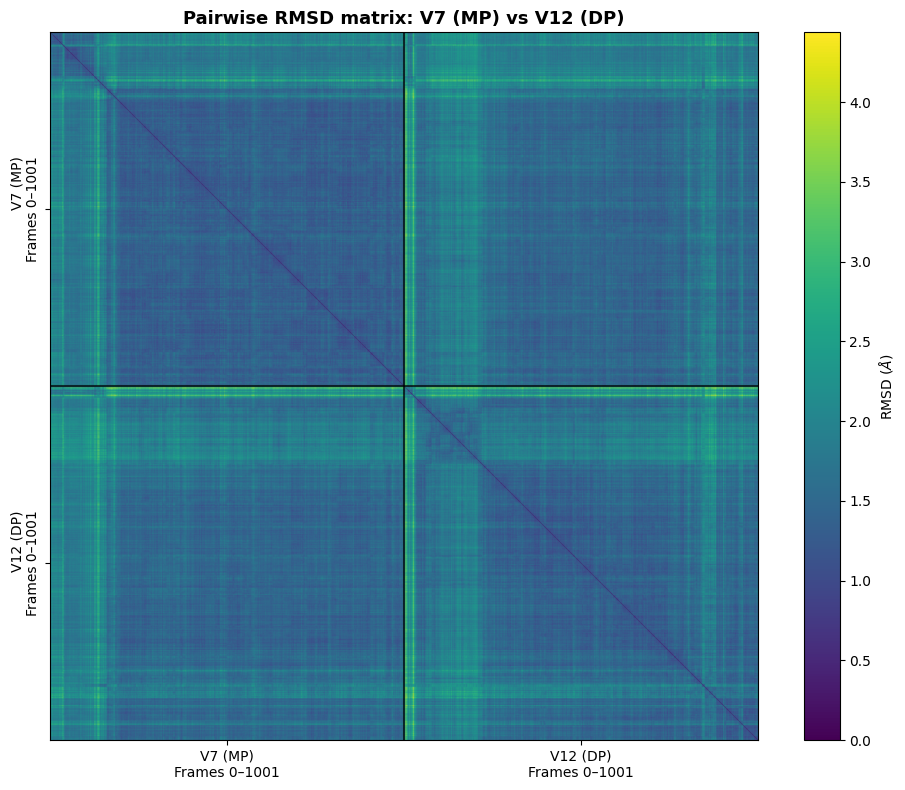

In [9]:
# 7. Assemble block matrix and plot heat-map
df_a    = pd.concat([df1, df2], ignore_index=True)
df_b    = pd.concat([df3, df4], ignore_index=True)
df_full = pd.concat([df_a, df_b], axis=1, ignore_index=True)

n_v7 = len(V7.trajectory)
fig  = plt.figure(figsize=(10, 8))
plt.imshow(df_full, cmap='viridis', origin='upper')
plt.axvline(x=n_v7, color='black', linewidth=1.5, alpha=0.7)
plt.axhline(y=n_v7, color='black', linewidth=1.5, alpha=0.7)
tick_pos    = [n_v7 // 2, n_v7 + n_v7 // 2]
tick_labels = [f'V7 (MP)\nFrames 0–{n_v7}', f'V12 (DP)\nFrames 0–{n_v7}']
plt.xticks(tick_pos, tick_labels, fontsize=10)
plt.yticks(tick_pos, tick_labels, fontsize=10, rotation=90, va='center')
plt.colorbar(label=r'RMSD ($\AA$)')
plt.title('Pairwise RMSD matrix: V7 (MP) vs V12 (DP)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'Figures/pw_rmsd_V7_V12.png'), bbox_inches='tight', dpi=150)
plt.show()

In [10]:
# 8. Save matrices to CSV
df1.to_csv(os.path.join(OUTPUT_DIR, 'Tables/pw_rmsd_V7_V7.csv'),   index=False)
df2.to_csv(os.path.join(OUTPUT_DIR, 'Tables/pw_rmsd_V7_V12.csv'),  index=False)
df3.to_csv(os.path.join(OUTPUT_DIR, 'Tables/pw_rmsd_V12_V7.csv'),  index=False)
df4.to_csv(os.path.join(OUTPUT_DIR, 'Tables/pw_rmsd_V12_V12.csv'), index=False)
df_full.to_csv(os.path.join(OUTPUT_DIR, 'Tables/pw_rmsd_full.csv'), index=False)
print('Matrices saved.')

Matrices saved.


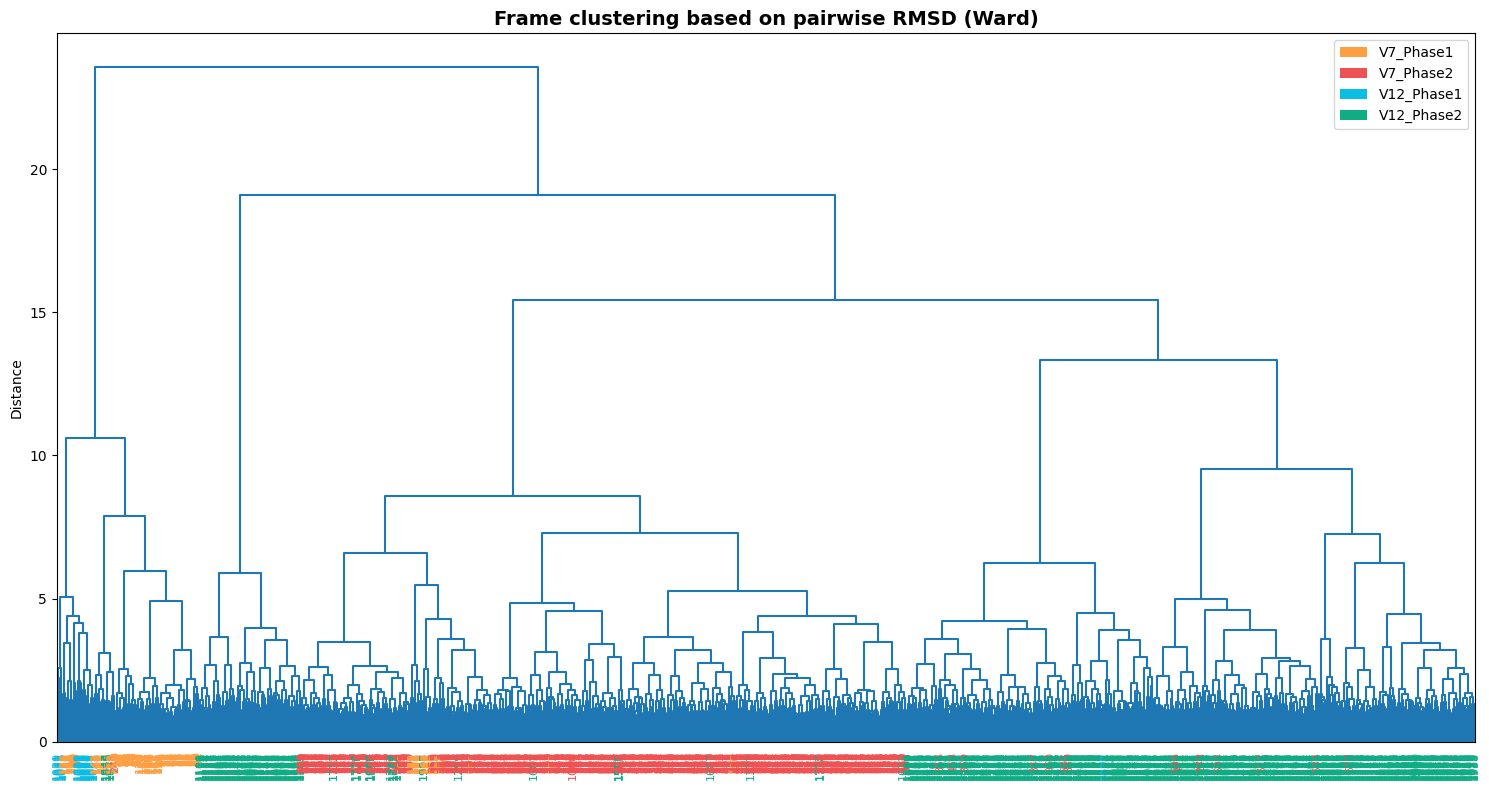

In [13]:
# 9. Hierarchical clustering — Ward dendrogram with phase colours
condensed = squareform(df_full, checks=False)
complete_clustering = linkage(condensed, method='ward')

def get_phase_key(abs_idx: int) -> str:
    if abs_idx < n_v7:
        return 'V7_Phase1' if abs_idx <= PHASE_LIMIT_V7 else 'V7_Phase2'
    local = abs_idx - n_v7
    return 'V12_Phase1' if local <= PHASE_LIMIT_V12 else 'V12_Phase2'

fig, ax = plt.subplots(figsize=(15, 8))
dendrogram(complete_clustering, leaf_font_size=8, orientation='top', ax=ax, color_threshold=0)
for lbl in ax.get_xmajorticklabels():
    if lbl.get_text().isdigit():
        lbl.set_color(COLOR_MAP[get_phase_key(int(lbl.get_text()))])

legend_elements = [Patch(facecolor=v, label=k) for k, v in COLOR_MAP.items()]
ax.legend(handles=legend_elements, loc='upper right', fontsize=10)
plt.title('Frame clustering based on pairwise RMSD (Ward)', fontsize=14, fontweight='bold')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()

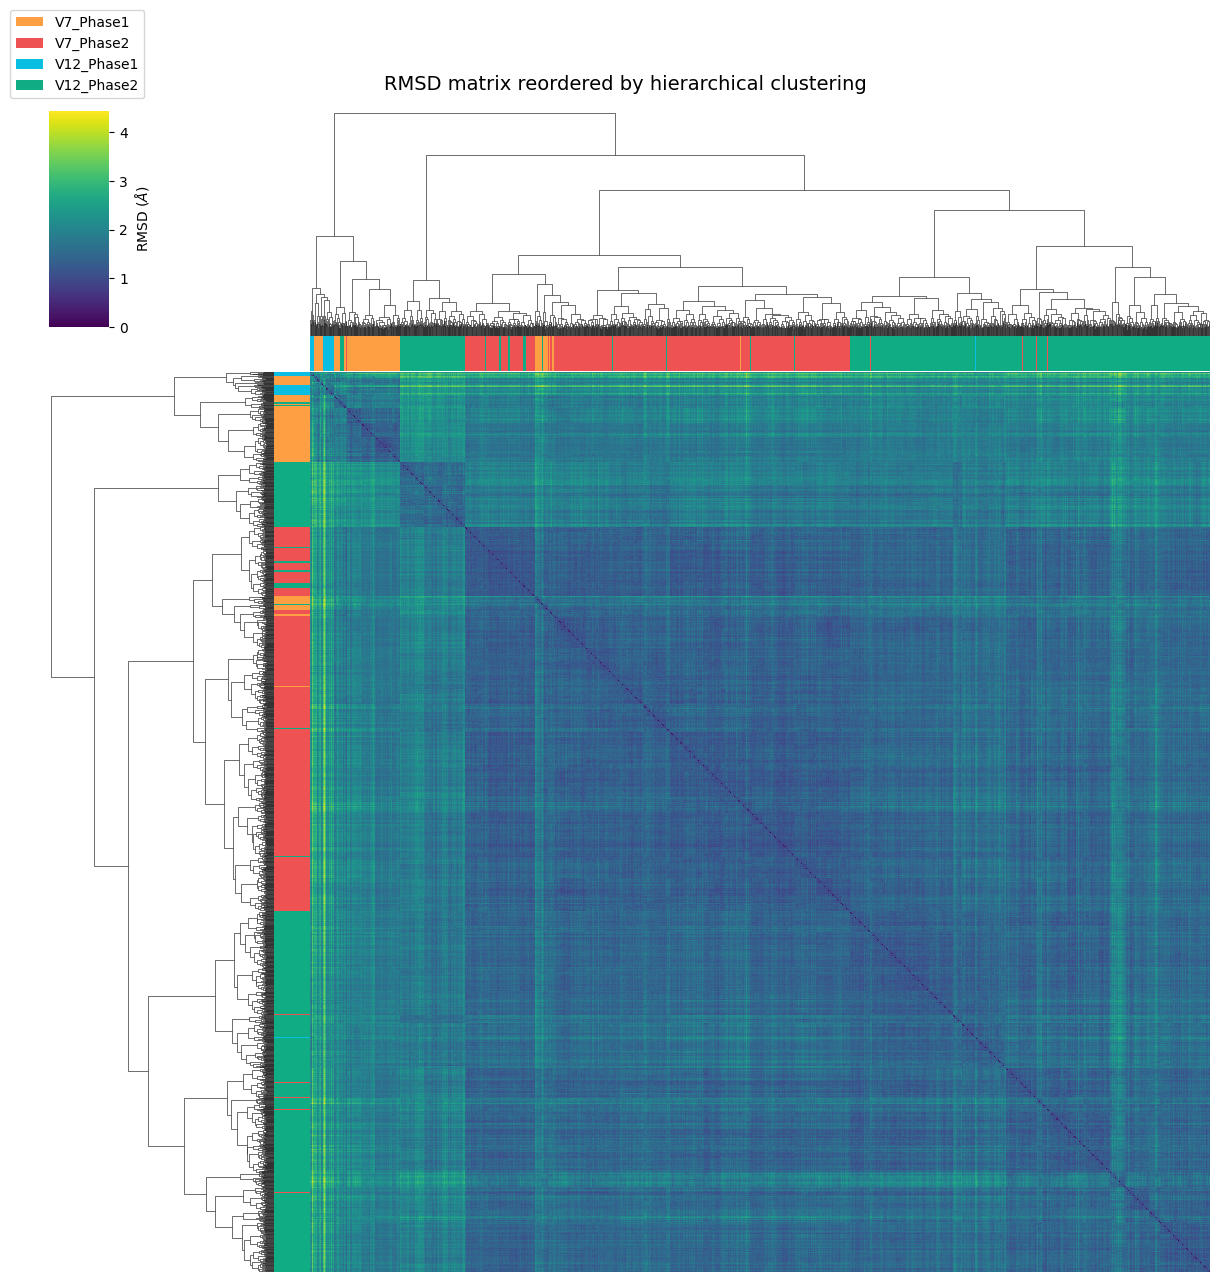

In [12]:
# 10. Clustermap with phase-coloured sidebars
meta_colors = [COLOR_MAP[get_phase_key(i)] for i in range(len(df_full))]

g = sns.clustermap(
    df_full,
    row_linkage=complete_clustering, col_linkage=complete_clustering,
    cmap='viridis', row_colors=meta_colors, col_colors=meta_colors,
    figsize=(12, 12), xticklabels=False, yticklabels=False,
    cbar_kws={'label': r'RMSD ($\AA$)'}
)
g.fig.suptitle('RMSD matrix reordered by hierarchical clustering', fontsize=14, y=1.01)
legend_elements = [Patch(facecolor=v, label=k) for k, v in COLOR_MAP.items()]
plt.gca().legend(handles=legend_elements, bbox_to_anchor=(1.7, 1.5), loc='upper right')
plt.show()

In [ ]:
# 11. Decision Tree classifier (phase labels from RMSD rows)
matrix_fixed = df_full.copy()
matrix_fixed.index   = np.arange(len(matrix_fixed))
matrix_fixed.columns = np.arange(len(matrix_fixed))

X = matrix_fixed.values
y = np.array([
    'Phase 1' if (i < n_v7 and i <= PHASE_LIMIT_V7) or
                 (i >= n_v7 and i - n_v7 <= PHASE_LIMIT_V12)
    else 'Phase 2'
    for i in range(len(matrix_fixed))
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1, stratify=y)

clf = DecisionTreeClassifier(max_depth=3)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print('--- Test set evaluation ---')
print(classification_report(y_test, y_pred))

fig, ax = plt.subplots(figsize=(8, 4))
plot_tree(clf, class_names=clf.classes_, filled=True, rounded=True, ax=ax)
plt.tight_layout()
plt.show()

In [ ]:
# 12. Stratified K-Fold cross-validation (10-fold)
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=1)
accuracies = []
for train_idx, test_idx in skf.split(X, y):
    clf.fit(X[train_idx], y[train_idx])
    accuracies.append(clf.score(X[test_idx], y[test_idx]))

print(f'Mean accuracy  : {mean(accuracies)*100:.1f}%')
print(f'Max accuracy   : {max(accuracies)*100:.1f}%')
print(f'Min accuracy   : {min(accuracies)*100:.1f}%')
print(f'Std deviation  : {stdev(accuracies):.4f}')